In [1]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [3]:
# Loading the files
train_data = pd.read_csv("C:\\Users\\salon\\OneDrive\\Desktop\\Task\\Task 5\\train.csv")
test_data = pd.read_csv("C:\\Users\\salon\\OneDrive\\Desktop\\Task\\Task 5\\test.csv")

In [4]:
# Understanding data
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Fetching columns 
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
# Getting information about data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# getting info about test data
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [8]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [10]:
# Since more than 50% of the values in cabin column are empty, so we need to drop that column
train_data.drop(columns ="Cabin", axis = 1, inplace = True)
test_data.drop(columns = "Cabin", axis = 1, inplace = True)

In [11]:
# Filling the null value of embarked column of train data with mode
mode_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'].fillna(mode_embarked, inplace = True)

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [13]:
# filling the empty values of age column of both train and test data with mean
mean_age_train = train_data['Age'].mean()
mean_age_test = test_data['Age'].mean()
train_data['Age'].fillna(mean_age_train, inplace = True)
test_data['Age'].fillna(mean_age_test, inplace = True)

In [14]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [15]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


In [16]:
# We need to fill the empty value of fare column of test data with mean
mean_fare = test_data['Fare'].mean()
test_data['Fare'].fillna(mean_fare, inplace = True)
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


In [17]:
# Checking duplicate value of train dataset
train_data.duplicated().sum()

0

In [18]:
# Checking duplicate value of test dataset
test_data.duplicated().sum()

0

In [19]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [20]:
# fetching the unique values of Ticket column and their counts.
train_data['Ticket'].value_counts()

347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: Ticket, Length: 681, dtype: int64

In [21]:
# Droping the columns which are of no use in modeling
train_data.drop(columns = ['Name', 'Ticket'], inplace = True)
test_data.drop(columns = ['Name', 'Ticket'], inplace = True)

In [22]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


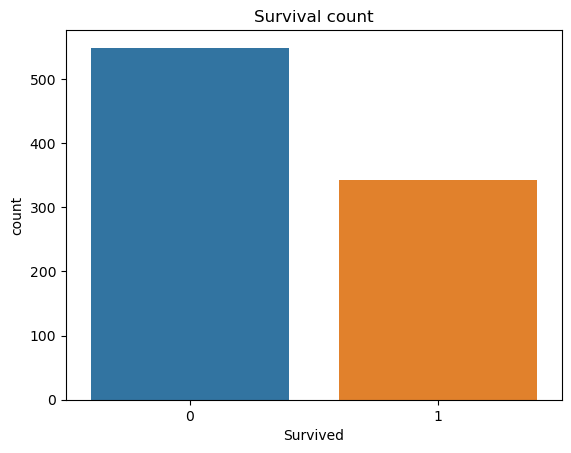

In [23]:
# Survival Count
sns.countplot(train_data, x = 'Survived')
plt.title('Survival count')
plt.show()

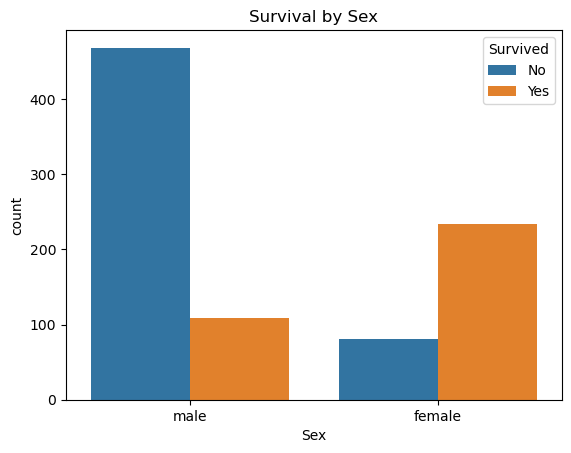

In [24]:
# Understanding the relationship with sex and survived columns
sns.countplot(train_data, x = 'Sex', hue = 'Survived')
plt.title("Survival by Sex")
plt.legend(title = 'Survived', labels = ['No', 'Yes'])
plt.show()

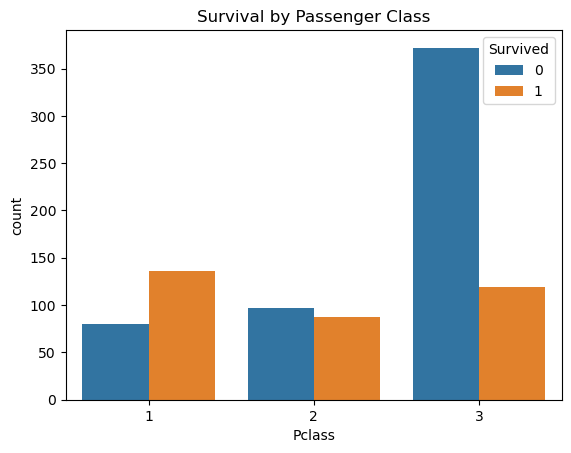

In [25]:
# Survival by passenger class
sns.countplot(train_data, x = 'Pclass', hue = 'Survived')
plt.title("Survival by Passenger Class")
plt.show()

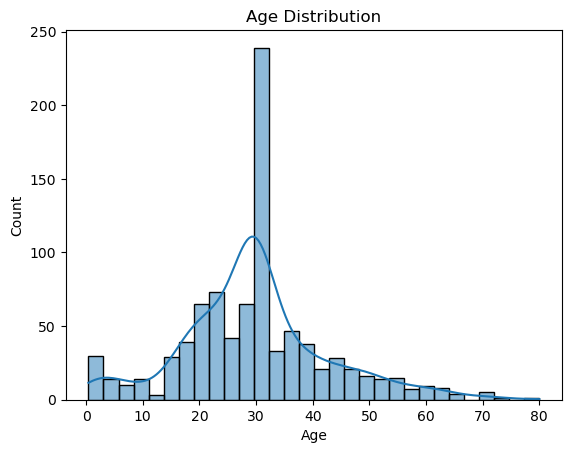

In [26]:
# Age distribution
sns.histplot(train_data['Age'], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

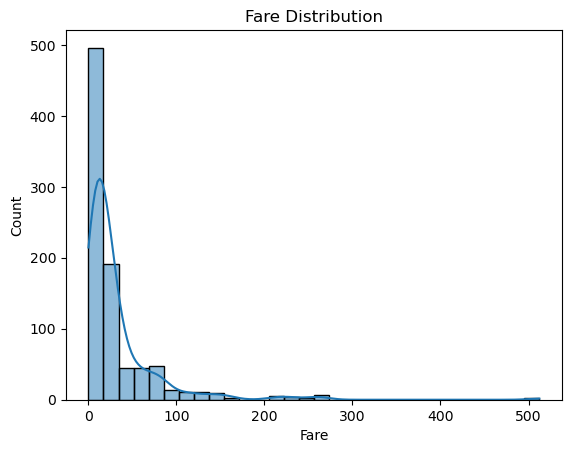

In [27]:
# Fare distribution
sns.histplot(train_data['Fare'], kde=True, bins=30)
plt.title("Fare Distribution")
plt.show()

In [28]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [29]:
# Creating FamilySize and IsAlone features as they are more helpful for modeling
for df in [train_data, test_data]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [30]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,male,22.0,1,0,7.2500,S,2,0
1,2,1,1,female,38.0,1,0,71.2833,C,2,0
2,3,1,3,female,26.0,0,0,7.9250,S,1,1
3,4,1,1,female,35.0,1,0,53.1000,S,2,0
4,5,0,3,male,35.0,0,0,8.0500,S,1,1


In [31]:
# Removing column "SibSp" and "Parch"
for df in [train_data, test_data]:
    df.drop(columns = ['SibSp', 'Parch'], inplace = True)
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,male,22.0,7.2500,S,2,0
1,2,1,1,female,38.0,71.2833,C,2,0
2,3,1,3,female,26.0,7.9250,S,1,1
3,4,1,1,female,35.0,53.1000,S,2,0
4,5,0,3,male,35.0,8.0500,S,1,1


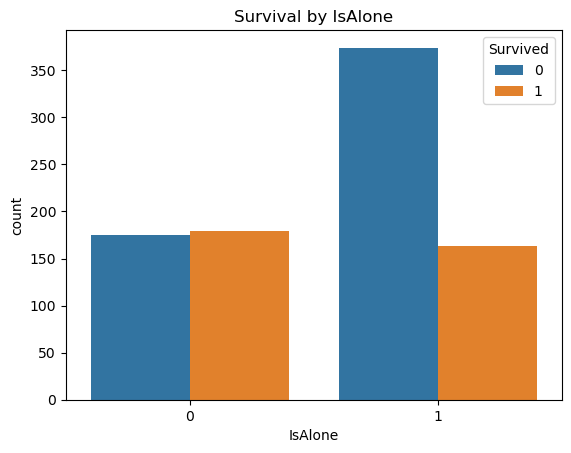

In [32]:
# Survival by IsAlone
sns.countplot(train_data, x = 'IsAlone', hue = 'Survived')
plt.title("Survival by IsAlone")
plt.show()

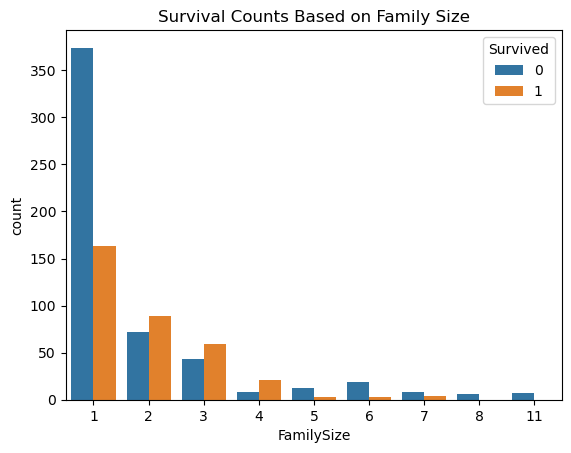

In [33]:
# Survival by FamilySize
sns.countplot(data=train_data, x='FamilySize', hue='Survived')
plt.title('Survival Counts Based on Family Size')
plt.show()

In [34]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,male,22.0,7.2500,S,2,0
1,2,1,1,female,38.0,71.2833,C,2,0
2,3,1,3,female,26.0,7.9250,S,1,1
3,4,1,1,female,35.0,53.1000,S,2,0
4,5,0,3,male,35.0,8.0500,S,1,1


In [35]:
# Encoding Sex: Male = 0, Female = 1
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,0,22.0,7.2500,S,2,0
1,2,1,1,1,38.0,71.2833,C,2,0
2,3,1,3,1,26.0,7.9250,S,1,1
3,4,1,1,1,35.0,53.1000,S,2,0
4,5,0,3,0,35.0,8.0500,S,1,1


In [36]:
# Encoding Embarked using one-hot encoding 
train_data = pd.get_dummies(train_data, columns=['Embarked'], drop_first=True)
test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=True)
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,7.2500,2,0,0,1
1,2,1,1,1,38.0,71.2833,2,0,0,0
2,3,1,3,1,26.0,7.9250,1,1,0,1
3,4,1,1,1,35.0,53.1000,2,0,0,1
4,5,0,3,0,35.0,8.0500,1,1,0,1


In [37]:
# Feature Scaling

scaler = StandardScaler()
train_data[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(train_data[['Age', 'Fare', 'FamilySize']])
test_data[['Age', 'Fare', 'FamilySize']] = scaler.transform(test_data[['Age', 'Fare', 'FamilySize']])
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,1,0,3,0,-0.592481,-0.502445,0.059160,0,0,1
1,2,1,1,1,0.638789,0.786845,0.059160,0,0,0
2,3,1,3,1,-0.284663,-0.488854,-0.560975,1,0,1
3,4,1,1,1,0.407926,0.420730,0.059160,0,0,1
4,5,0,3,0,0.407926,-0.486337,-0.560975,1,0,1


In [38]:
# Split Train data 

X = train_data.drop(columns= ['Survived', 'PassengerId'])  # Features
y = train_data['Survived']  # Target

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest

In [39]:
# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)  # Initialize model
rf_model.fit(X_train, y_train)                      # Train model
rf_pred = rf_model.predict(X_val)                   # Predict on validation data

# Evaluation
print("🌲 Random Forest")
print("Accuracy:", accuracy_score(y_val, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, rf_pred))
print("Classification Report:\n", classification_report(y_val, rf_pred))

🌲 Random Forest
Accuracy: 0.8324022346368715
Confusion Matrix:
 [[93 12]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



# XGBoost Classifier

In [40]:
# XGBoost Classifier
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)  # Initialize model
xgb_model.fit(X_train, y_train)  # Train model
xgb_pred = xgb_model.predict(X_val)  # Predict

# Evaluation
print("\n⚡ XGBoost")
print("Accuracy:", accuracy_score(y_val, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, xgb_pred))
print("Classification Report:\n", classification_report(y_val, xgb_pred))


⚡ XGBoost
Accuracy: 0.7932960893854749
Confusion Matrix:
 [[87 18]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



# Support Vector Machine (SVM)

In [41]:
# Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', random_state=42)  # Initialize model with linear kernel
svm_model.fit(X_train, y_train)  # Train model
svm_pred = svm_model.predict(X_val)  # Predict

# Evaluation
print("\n📈 Support Vector Machine (SVM)")
print("Accuracy:", accuracy_score(y_val, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, svm_pred))
print("Classification Report:\n", classification_report(y_val, svm_pred))


📈 Support Vector Machine (SVM)
Accuracy: 0.7821229050279329
Confusion Matrix:
 [[89 16]
 [23 51]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



# Logistic Regression

In [42]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)  # Initialize model with max_iter=1000
logreg.fit(X_train, y_train)  # Train model
logreg_pred = logreg.predict(X_val)  # Predict

# Evaluation
print("\n🔍 Logistic Regression")
print("Accuracy:", accuracy_score(y_val, logreg_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, logreg_pred))
print("Classification Report:\n", classification_report(y_val, logreg_pred))


🔍 Logistic Regression
Accuracy: 0.8044692737430168
Confusion Matrix:
 [[91 14]
 [21 53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



# Predict Test data using Random Forest model as it performs the best

In [43]:
test_data.head()

,PassengerId,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,892,3,0,0.369449,-0.490783,-0.560975,1,1,0
1,893,3,1,1.331378,-0.507479,0.059160,0,0,1
2,894,2,0,2.485693,-0.453367,-0.560975,1,1,0
3,895,3,0,-0.207709,-0.474005,-0.560975,1,0,1
4,896,3,1,-0.592481,-0.401017,0.679295,0,0,1


In [44]:
# Drop unnecessary columns from test data
X_test = test_data.drop(columns='PassengerId')

In [45]:
# Predict using Random Forest model
test_predictions = rf_model.predict(X_test)

In [46]:
# Create submission dataframe
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': test_predictions
})

In [47]:
# Save submission to CSV
submission.to_csv('titanic_submission.csv', index=False)

In [48]:
print("✅ Final submission file saved as 'titanic_submission.csv'")

✅ Final submission file saved as 'titanic_submission.csv'
